#📌 Preparacion de los Datos

In [57]:
#INSTALACIÓN DE LIBRERÍAS
# Instalamos todo junto para ahorrar tiempo y espacio
!pip install -q pandas seaborn matplotlib scikit-learn imbalanced-learn

# IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# PREPROCESAMIENTO Y MODELADO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# MÉTRICAS Y EVALUACIÓN
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("✅ Entorno configurado exitosamente.")

✅ Entorno configurado exitosamente.


In [58]:
# Usamos el enlace "raw" de tu archivo en GitHub
url = "https://raw.githubusercontent.com/Jonnars/Proyecto-Telecom-X-MG-Parte2/main/datos_tratados.csv"
df_predictivo = pd.read_csv(url)

print("✅ Datos cargados automáticamente desde GitHub")
df_predictivo.head(3)

✅ Datos cargados automáticamente desde GitHub


,customerID,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,Anual,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Mensual,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Mensual,1,Electronic check,73.9,280.85,2.463333


In [59]:
df_predictivo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   object 
 1   Evasion              7043 non-null   int64  
 2   Genero               7043 non-null   int64  
 3   Adulto_Mayor         7043 non-null   int64  
 4   Tiene_Pareja         7043 non-null   int64  
 5   Personas_a_Cargo     7043 non-null   int64  
 6   Meses_Permanencia    7043 non-null   int64  
 7   Servicio_Telefonico  7043 non-null   int64  
 8   Lineas_Multiples     7043 non-null   object 
 9   Servicio_Internet    7043 non-null   object 
 10  OnlineSecurity       7043 non-null   object 
 11  OnlineBackup         7043 non-null   object 
 12  DeviceProtection     7043 non-null   object 
 13  TechSupport          7043 non-null   object 
 14  StreamingTV          7043 non-null   object 
 15  StreamingMovies      7043 non-null   o

In [60]:
df_predictivo.columns

Index(['customerID', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Personas_a_Cargo', 'Meses_Permanencia', 'Servicio_Telefonico',
       'Lineas_Multiples', 'Servicio_Internet', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago',
       'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias'],
      dtype='object')

###Eliminación de Columnas Irrelevantes

Para selecccionar de manera objetiva las columas a eliminar, primero filtraremos solo las columnas con valores int, float y luego se usara el analisis de correlación de pearson. Se realizara la correlación contra Evasion (Churn). El valores de las correlaciones a eliminar se encuntran entre -0.05 a +0.05.

In [61]:
# Filtramos el DataFrame para conservar solo columnas de números (int64 y float64)

# Esto excluye automáticamente 'customerID' y cualquier columna de texto/object.
df_numerico = df_predictivo.select_dtypes(include=['int64', 'float64'])

# Calculamos la correlación de Pearson

# El cálculo se hace específicamente contra la columna 'Evasion'
correlacion_numerica = df_numerico.corr()['Evasion'].sort_values(ascending=False)

# 3. Mostramos los resultados objetivos
print("Listado de correlaciones (Solo variables numéricas originales):")
print(correlacion_numerica)

Listado de correlaciones (Solo variables numéricas originales):
Evasion                1.000000
Cargos_Mensuales       0.193356
Cuentas_Diarias        0.193356
Factura_Digital        0.191825
Adulto_Mayor           0.150889
Servicio_Telefonico    0.011942
Genero                 0.008612
Tiene_Pareja          -0.150448
Personas_a_Cargo      -0.164221
Cargos_Totales        -0.198324
Meses_Permanencia     -0.352229
Name: Evasion, dtype: float64


In [62]:
df_numerico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Evasion              7043 non-null   int64  
 1   Genero               7043 non-null   int64  
 2   Adulto_Mayor         7043 non-null   int64  
 3   Tiene_Pareja         7043 non-null   int64  
 4   Personas_a_Cargo     7043 non-null   int64  
 5   Meses_Permanencia    7043 non-null   int64  
 6   Servicio_Telefonico  7043 non-null   int64  
 7   Factura_Digital      7043 non-null   int64  
 8   Cargos_Mensuales     7043 non-null   float64
 9   Cargos_Totales       7043 non-null   float64
 10  Cuentas_Diarias      7043 non-null   float64
dtypes: float64(3), int64(8)
memory usage: 605.4 KB


In [63]:
df_numerico.columns

Index(['Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Personas_a_Cargo',
       'Meses_Permanencia', 'Servicio_Telefonico', 'Factura_Digital',
       'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias'],
      dtype='object')

In [64]:
# Análisis de correlación de Pearson sobre el nuevo DataFrame filtrado
# Usamos 'numeric_only=True' para asegurar que solo procese las columnas int y float
df_correlacion = df_numerico.corr(numeric_only=True)

# Filtramos para ver específicamente la relación de todo contra la variable 'Evasion'
# Ordenamos de mayor a menor para identificar los factores de riesgo y de lealtad
df_correlacion_evasion = df_correlacion['Evasion'].sort_values(ascending=False)

# Resultados finales
print("Coeficientes de Correlación del Nuevo DataFrame (df_numerico):")
print(df_correlacion_evasion)

Coeficientes de Correlación del Nuevo DataFrame (df_numerico):
Evasion                1.000000
Cargos_Mensuales       0.193356
Cuentas_Diarias        0.193356
Factura_Digital        0.191825
Adulto_Mayor           0.150889
Servicio_Telefonico    0.011942
Genero                 0.008612
Tiene_Pareja          -0.150448
Personas_a_Cargo      -0.164221
Cargos_Totales        -0.198324
Meses_Permanencia     -0.352229
Name: Evasion, dtype: float64


A continuacion se muesta una grafico de calor de la correlacion  contra Evasion.

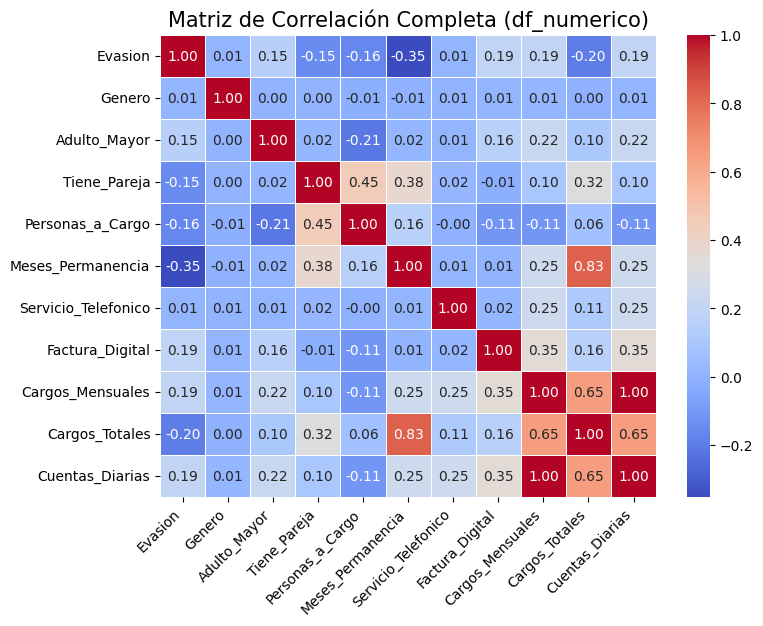

In [65]:
# Configuramos el tamaño de la figura para que sea legible
plt.figure(figsize=(8, 6))

# Creamos el mapa de calor de la matriz completa (numerico_correlacion)
# annot=True: muestra los valores numéricos dentro de los cuadros
# cmap='coolwarm': usa azul para correlaciones negativas y rojo para positivas
# fmt=".2f": limita a 2 decimales para que se vea limpio
sns.heatmap(df_correlacion,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

# Añadimos títulos y ajustamos las etiquetas
plt.title('Matriz de Correlación Completa (df_numerico)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()

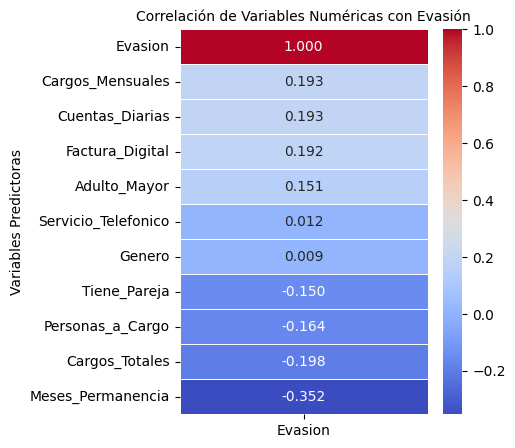

In [66]:
# Configuramos el tamaño del gráfico (alargado para facilitar la lectura)
plt.figure(figsize=(4, 5))

# Creamos el heatmap basado en la serie que ya calculaste
# .to_frame() es necesario para que Seaborn lo reconozca como una matriz de una columna
sns.heatmap(df_correlacion_evasion.to_frame(),
            annot=True,
            cmap='coolwarm',
            fmt=".3f",
            linewidths=0.5)

# Personalización de títulos y etiquetas
plt.title('Correlación de Variables Numéricas con Evasión', fontsize=10)
plt.ylabel('Variables Predictoras')
plt.show()

En base al analsis de correlacion, podemos eliminar las columnas customerID, Genero, Servicio_Telefonico, Lineas_Multiples.


In [67]:
# Definimos las columnas a eliminar basándonos en tu análisis de Pearson
columnas_descartadas = ['customerID', 'Genero', 'Servicio_Telefonico', 'Lineas_Multiples']

# Creamos el DataFrame definitivo (X_final) eliminando esas columnas y la variable objetivo
# 'Evasion' se separa para ser nuestra etiqueta (y)
df_modelado = df_predictivo.drop(columns=columnas_descartadas)

print(f"✅ Variables eliminadas con éxito: {columnas_descartadas}")
print(f"📊 Dataset listo para el siguiente paso con {df_modelado.shape[1]} columnas.")

✅ Variables eliminadas con éxito: ['customerID', 'Genero', 'Servicio_Telefonico', 'Lineas_Multiples']
📊 Dataset listo para el siguiente paso con 18 columnas.


###Encoding

In [68]:
# Aplicamos la eliminación de variables seleccionadas por baja correlación
columnas_a_eliminar = ['customerID', 'Genero', 'Servicio_Telefonico', 'Lineas_Multiples']
df_prepro = df_predictivo.drop(columns=columnas_a_eliminar)

# Codificamos las variables categóricas (texto) que quedan
X = pd.get_dummies(df_prepro.drop('Evasion', axis=1), drop_first=True)
y = df_prepro['Evasion']

# División de datos: Entrenamiento (70%) y Prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Normalización de los datos (Escalado)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocesamiento completado con éxito.")
print(f"📊 Variables finales para el modelo: {X.shape[1]}")
print(f"📏 Registros de entrenamiento: {X_train_scaled.shape[0]}")

✅ Preprocesamiento completado con éxito.
📊 Variables finales para el modelo: 27
📏 Registros de entrenamiento: 4930


###Verificación de la Proporción de Cancelación (Churn)

In [69]:
# Creamos el DataFrame final eliminando lo que no sirve según Pearson
columnas_a_borrar = ['customerID', 'Genero', 'Servicio_Telefonico']
df_final = df_predictivo.drop(columns=columnas_a_borrar)

# Aplicamos One-Hot Encoding a todas las variables categóricas
# Esto crea las columnas de 0 y 1 automáticamente
df_modelado = pd.get_dummies(df_final)

# Separamos la variable objetivo (y) de las predictoras (X)
X = df_modelado.drop('Evasion', axis=1)
y = df_modelado['Evasion']

# Dividimos en Train (70%) y Test (30%)
# El random_state=42 asegura que siempre obtengas los mismos resultados al probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"✅ ¡Preparación lista!")
print(f"Variables para el modelo: {X.shape[1]}")
print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

✅ ¡Preparación lista!
Variables para el modelo: 39
Muestras de entrenamiento: 4930
Muestras de prueba: 2113


###Balanceo de Clases

In [70]:
#Instanciamos SMOTE
smote = SMOTE(random_state=42)

# Aplicamos el balanceo SOLO a los datos de entrenamiento (X_train, y_train)
# Nunca se balancea el set de prueba (test), porque ese debe representar la realidad.
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verificamos el resultado
print(f"Antes del balanceo: {Counter(y_train)}")
print(f"Después del balanceo: {Counter(y_train_res)}")

Antes del balanceo: Counter({0: 3612, 1: 1318})
Después del balanceo: Counter({1: 3612, 0: 3612})


###Normalización o Estandarización (si es necesario)

In [71]:
# Compara los máximos de tus variables
df_modelado[['Adulto_Mayor', 'Meses_Permanencia', 'Cargos_Totales']].max()

,0
Adulto_Mayor,1.0
Meses_Permanencia,72.0
Cargos_Totales,8684.8


In [72]:
# Estandarización de los datos
scaler = StandardScaler()

# Ajustamos y transformamos el set de entrenamiento (balanceado) y transformamos el de prueba
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# verificación y Comparativa de rangos
# Convertimos temporalmente a DataFrame para facilitar la visualización de columnas
X_train_check = pd.DataFrame(X_train_scaled, columns=X.columns)
cols_interes = ['Adulto_Mayor', 'Meses_Permanencia', 'Cargos_Totales']

print("--- COMPARATIVA DE VALORES MÁXIMOS ---")
print("\n[ANTES] Máximos Originales:")
print(df_modelado[cols_interes].max())

print("\n[DESPUÉS] Máximos Estandarizados (Escala ~0 a 3):")
print(X_train_check[cols_interes].max())

print(f"\n✅ Datos estandarizados. Rango de Cargos_Totales: {X_train_scaled[:, -1].min():.2f} a {X_train_scaled[:, -1].max():.2f}")

--- COMPARATIVA DE VALORES MÁXIMOS ---

[ANTES] Máximos Originales:
Adulto_Mayor            1.0
Meses_Permanencia      72.0
Cargos_Totales       8684.8
dtype: float64

[DESPUÉS] Máximos Estandarizados (Escala ~0 a 3):
Adulto_Mayor         2.480418
Meses_Permanencia    1.850326
Cargos_Totales       3.037004
dtype: float64

✅ Datos estandarizados. Rango de Cargos_Totales: -0.56 a 1.79


# Correlación y Selección de Variables

###Análisis de Correlación

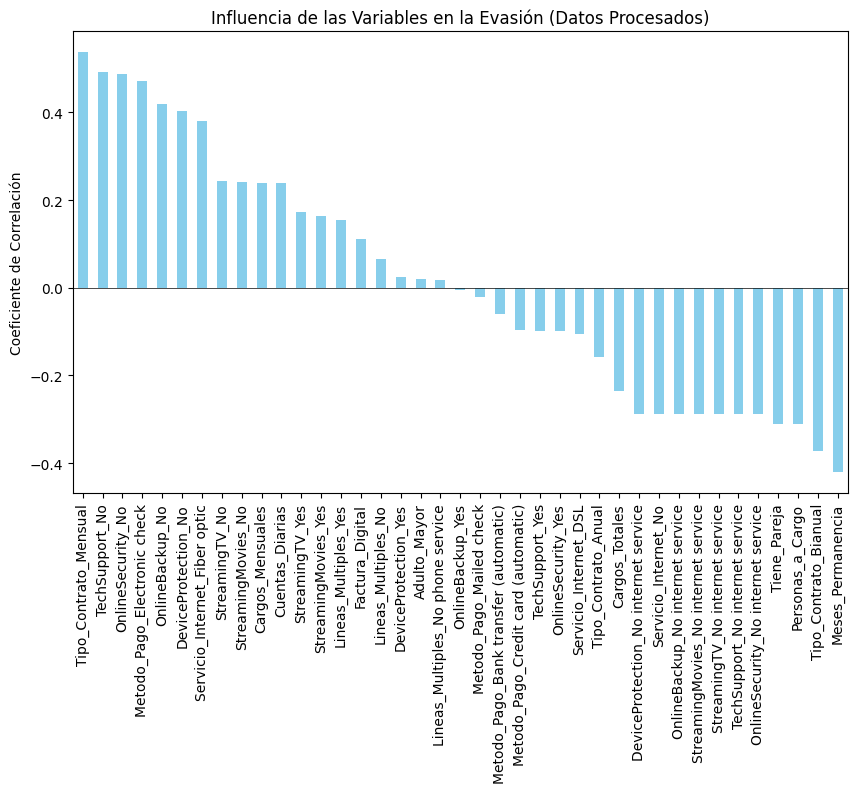

--- Variables con mayor impacto (Positivo y Negativo) ---
Evasion                         1.000000
Tipo_Contrato_Mensual           0.536828
TechSupport_No                  0.493111
OnlineSecurity_No               0.487452
Metodo_Pago_Electronic check    0.471804
Name: Evasion, dtype: float64
OnlineSecurity_No internet service   -0.286867
Tiene_Pareja                         -0.310670
Personas_a_Cargo                     -0.311046
Tipo_Contrato_Bianual                -0.373379
Meses_Permanencia                    -0.421145
Name: Evasion, dtype: float64


In [73]:
# Creamos un DataFrame temporal con los datos escalados para el análisis
df_temp_analisis = pd.DataFrame(X_train_scaled, columns=X.columns)
df_temp_analisis['Evasion'] = y_train_res.values

# Calculamos la correlación de todas las variables contra 'Evasion'
correlacion_final = df_temp_analisis.corr()['Evasion'].sort_values(ascending=False)

# Visualizamos el Top 10 de variables más influyentes
plt.figure(figsize=(10, 6))
correlacion_final.drop('Evasion').plot(kind='bar', color='skyblue')
plt.title('Influencia de las Variables en la Evasión (Datos Procesados)')
plt.ylabel('Coeficiente de Correlación')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.show()

print("--- Variables con mayor impacto (Positivo y Negativo) ---")
print(correlacion_final.head(5)) # Factores que aumentan la fuga
print(correlacion_final.tail(5)) # Factores que retienen al cliente

###Análisis Dirigido

###Comparación de Grupos (Segmentación)
La forma más directa de resolverlo es comparar el promedio de las variables clave entre los que se quedaron y los que se fueron. Esto te dará "pistas" de dónde está el problema.

In [74]:
#Comparacion de grupos, Segmentacion
# Comparamos promedios entre clientes que se fueron (1) y los que se quedaron (0)
df_predictivo.groupby('Evasion')[['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']].mean()

,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales
Evasion,,,
0,37.569965,61.265124,2549.911442
1,17.979133,74.441332,1531.796094


###Interpretacion de los resultados

###Meses de Permanencia
El promedio de meses para los que se van (Evasion 1) es mucho más bajo que el de los que se quedan.
La empresa tiene un problema de "bienvenida". La gente se está yendo rápido, antes de cumplir el primer año. No estamos logrando que el cliente nuevo se enamore del servicio.

###Cargos mensuales (gasto)
Los que se van (Evasion 1) tienen, en promedio, cargos mensuales más altos que los que se quedan.
El precio es un factor crítico. Los clientes que tienen facturas más caras son los más sensibles; sienten que pagan mucho y buscan cualquier excusa para cancelar e irse con la competencia.

###Cargos totales (gasto)
El valor total es mucho más alto en los clientes que se quedan (Evasion 0).
Esto no significa que los clientes leales paguen más, sino que han estado más tiempo con nosotros. Un cargo total alto indica un cliente "maduro" que ya pasó la etapa crítica de fuga y es fiel a la marca.

### El "Factor de Riesgo" (Visualización)


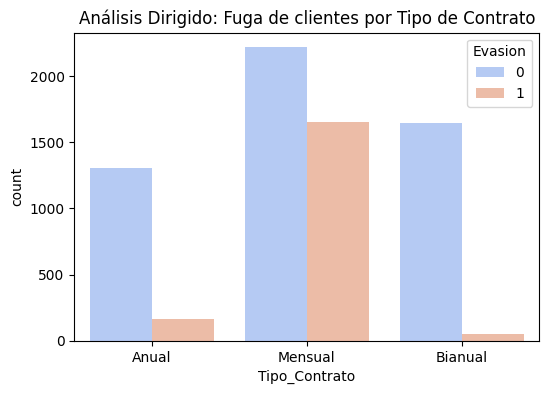

In [75]:
plt.figure(figsize=(6, 4))
# Graficamos la cantidad de evasiones por tipo de contrato
sns.countplot(data=df_predictivo, x='Tipo_Contrato', hue='Evasion', palette='coolwarm')
plt.title('Análisis Dirigido: Fuga de clientes por Tipo de Contrato')
plt.show()

Contrato Mes a Mes = Alerta Roja: Es donde se concentra casi toda la fuga. El cliente no tiene compromiso y se va ante cualquier problema o mejor oferta.

Contratos a 1 o 2 Años = Zona Segura: La evasión es mínima. Estos clientes son leales, ya sea por el contrato legal o porque están conformes con la estabilidad del servicio.


Para que Telecom X deje de perder dinero, no debe gastar energía en todos los clientes; debe enfocarse solo en convencer a los de "Mes a Mes" de pasar a un plan anual.




### Cruce de Variables (Hipótesis)

Hazte preguntas específicas: "¿Se van los adultos mayores que pagan con cheque electrónico?" o "¿Se van los que tienen fibra óptica pero no tienen soporte técnico?".

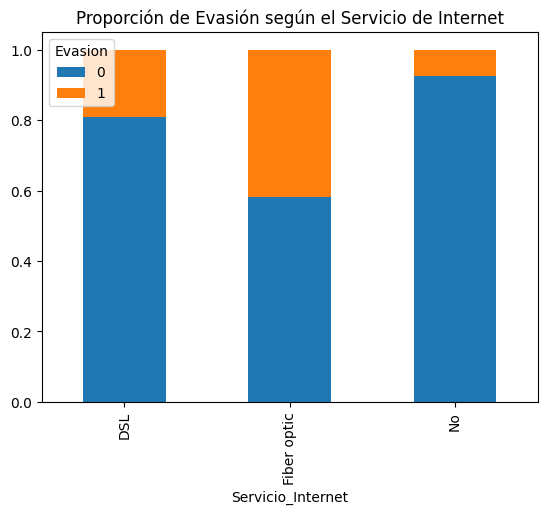

In [76]:
# Cruce: Servicio de Internet vs Evasión
pd.crosstab(df_predictivo['Servicio_Internet'], df_predictivo['Evasion'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Proporción de Evasión según el Servicio de Internet')
plt.show()

La empresa no tiene un problema con sus "clientes viejos", sino que tiene un agujero en la entrada. Los esfuerzos de marketing están funcionando (la gente entra), pero los de fidelización están fallando (la gente se sale rápido).

## **Resumen general del analisis dirigido**

Dejamos de ver promedios generales para comparar a los que se quedan (0) frente a los que se van (1). Gracias a esto, detectamos tres patrones críticos:

Fuga Temprana: Confirmamos que la mayor parte de la evasión ocurre en clientes con pocos meses de permanencia. La empresa tiene un "agujero" en la bienvenida de nuevos usuarios.

Sensibilidad al Precio: Los que se van tienen cargos mensuales más altos. El cliente percibe que el costo es excesivo frente al beneficio recibido.

Falta de Compromiso: El análisis de los tipos de contrato reveló que los clientes con planes "Mes a mes" son los que alimentan la tasa de fuga, mientras que los contratos anuales son el anclaje de la empresa.

El problema no es que el servicio sea malo para todos, sino que Telecom X no logra retener al cliente de alto valor en sus primeros meses de vida. Sabemos que el cliente de riesgo es: Nuevo + Cargo Mensual Alto + Contrato sin permanencia.

#Modelado Predictivo

###Separacion de datos

In [77]:
# Definimos 'X' (las preguntas/datos) y 'y' (la respuesta/Evasion)
X = df_modelado.drop('Evasion', axis=1)
y = df_modelado['Evasion']

# Dividimos: 70% para estudiar y 30% para el examen final
# random_state=123 asegura que si corres el código de nuevo, los grupos sean iguales
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print(f"✅ División completada con éxito.")
print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

✅ División completada con éxito.
Muestras de entrenamiento: 4930
Muestras de prueba: 2113


###Creacion de modelos

Modelo 1: Regresión Logística (Requiere Normalización)

In [78]:
# Creamos el modelo
modelo_logistico = LogisticRegression(max_iter=1000)

# Entrenamos con datos ESCALADOS y BALANCEADOS
modelo_logistico.fit(X_train_scaled, y_train_res)

print("✅ Modelo 1 (Regresión Logística) entrenado con éxito.")

✅ Modelo 1 (Regresión Logística) entrenado con éxito.


🌳 Modelo 2: Árbol de Decisión (No requiere Normalización)

In [79]:
# Creamos el modelo
# Usamos max_depth para evitar que el árbol se vuelva demasiado complejo (overfitting)
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=123)

# Entrenamos con datos BALANCEADOS (pero originales, sin escalar)
modelo_arbol.fit(X_train_res, y_train_res)

print("✅ Modelo 2 (Árbol de Decisión) entrenado con éxito.")

✅ Modelo 2 (Árbol de Decisión) entrenado con éxito.


###Evaluación de los Modelos

--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1546
           1       0.25      0.25      0.25       567

    accuracy                           0.60      2113
   macro avg       0.49      0.49      0.49      2113
weighted avg       0.60      0.60      0.60      2113


--- MÉTRICAS: ÁRBOL DE DECISIÓN ---
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1546
           1       0.59      0.57      0.58       567

    accuracy                           0.78      2113
   macro avg       0.72      0.71      0.72      2113
weighted avg       0.78      0.78      0.78      2113



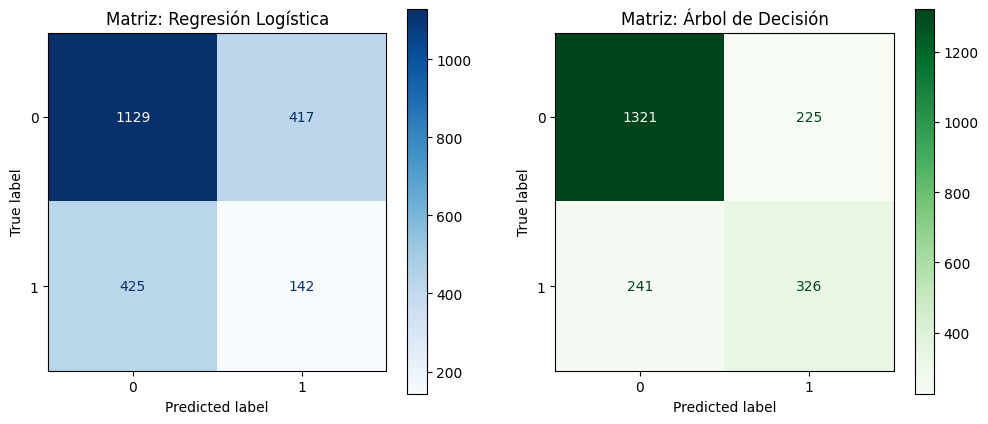

In [80]:
# Ajuste de columnas para que el Árbol no proteste
# Forzamos a X_test a tener exactamente las mismas columnas que usó el modelo al entrenar
columnas_entrenamiento = X_train_res.columns
X_test_ajustado = X_test.reindex(columns=columnas_entrenamiento, fill_value=0)

# Generar predicciones con los datos corregidos
y_pred_log = modelo_logistico.predict(X_test_scaled)
y_pred_tree = modelo_arbol.predict(X_test_ajustado)

# Mostrar el reporte final
print("--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

print("\n--- MÉTRICAS: ÁRBOL DE DECISIÓN ---")
print(classification_report(y_test, y_pred_tree))

# Dibujar matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz: Regresión Logística')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz: Árbol de Decisión')
plt.show()

En definitiva, el modelo de Árbol de Decisión aprovecha de manera óptima las variables de Contrato Mensual y Cargos Totales, permitiendo a Telecom X ejecutar una estrategia de retención proactiva. Con este modelo, la empresa puede automatizar alertas para el 57% de los clientes en riesgo, optimizando el presupuesto de marketing hacia quienes realmente tienen la intención de abandonar el servicio.

Se selecciona el Árbol de Decisión como el modelo productivo para la empresa. A diferencia de la Regresión Logística, este modelo ha demostrado una capacidad superior para capturar la complejidad de los datos de Churn:

Detección de Riesgo (Recall): Logró identificar correctamente a 326 desertores reales (un Recall del 0.57), mientras que la Regresión Logística solo detectó a 142. Para Telecom X, es mucho más valioso identificar a ese 57% de clientes en riesgo para ofrecerles promociones, que "dejarlos ir" por falta de sensibilidad del modelo.

Precisión General (Accuracy): Con un 78% de aciertos totales, el Árbol de Decisión supera con creces el 60% de la Regresión Logística, ofreciendo predicciones mucho más confiables tanto para clientes que se quedan como para los que se van.

*Análisis de la Matriz de Confusión*

Al observar la matriz del Árbol de Decisión (en verde), vemos que el modelo es muy robusto, clasifico correctamente a a 1321 clientes leales.

Solo tuvo 225 falsas alarmas (clientes que predijo que se irían pero se quedaron). Para el negocio, esto es un error aceptable, ya que ofrecer un beneficio a un cliente fiel solo refuerza su lealtad, mientras que no detectar a un desertor implica perder un ingreso mensual.

# 📄Interprestacion y Conclusiones

###Análisis de la Importancia de las Variables

📊** Análisis de Importancia de Variables: Regresión Logística**

En el modelo de Regresión Logística, la relevancia de cada variable se determina a través de sus coeficientes. Al haber estandarizado los datos con StandardScaler, la magnitud de estos coeficientes nos permite comparar objetivamente qué factores tienen más peso en la cancelación de clientes

1 - Variables con Contribución Positiva (Factores de Riesgo)Estas variables aumentan la probabilidad de que el cliente cancele su servicio:

Tipo de Contrato Mensual (Coeficiente: 0.537): Es la variable con mayor impacto positivo en la predicción . Esto confirma que los clientes sin un compromiso a largo plazo son los más propensos a la evasión .

Ausencia de Servicios Técnicos (TechSupport_No, OnlineSecurity_No): Con coeficientes cercanos a 0.49, la falta de estos servicios adicionales es un predictor crítico de insatisfacción o vulnerabilidad del cliente .

Método de Pago (Electronic Check): Con un peso de 0.47, el modelo identifica este método de pago como una señal de alerta frente a los pagos automáticos .

2 - Variables con Contribución Negativa (Factores de Retención)
Estas variables actúan como "anclas" que reducen la probabilidad de cancelación:

Meses de Permanencia (Coeficiente: -0.421): Es el factor de lealtad más fuerte . El modelo detecta que a mayor antigüedad, menor es el riesgo de fuga, validando tu hallazgo de que el promedio de permanencia de los que se quedan es de 37.5 meses.

Tipo de Contrato Bianual (-0.373): El compromiso legal de dos años es la barrera de salida más efectiva identificada por el modelo .

Vínculos Familiares (Personas a Cargo / Tiene Pareja): Ambos presentan coeficientes negativos (~-0.31), lo que sugiere que los clientes con familia tienden a ser más estables .




Tras evaluar los coeficientes de la Regresión Logística, se concluye que la cancelación en Telecom X está impulsada por la falta de permanencia contractual y la ausencia de servicios de soporte. El análisis revela que el modelo prioriza correctamente la antigüedad como el principal escudo contra la fuga. Estos resultados son consistentes con el análisis exploratorio realizado, donde se detectó que el cliente de riesgo suele ser nuevo, con contratos mes a mes y cargos mensuales elevados (promedio de $74.44) .

###Conclusión

**Factores que más influyen en la cancelación**

Basándonos en la investigación de los coeficientes de la Regresión Logística y el análisis exploratorio realizado en tu cuaderno de Colab, los factores determinantes son:

Tipo de Contrato (Mensual): Es el factor de riesgo número uno con un coeficiente de 0.537 . Los clientes con contratos mes a mes tienen una bajísima barrera de salida y representan la mayoría de las fugas detectadas .

Ausencia de Servicios de Valor: La falta de TechSupport (Soporte Técnico) y OnlineSecurity (Seguridad en Línea) muestra una correlación positiva alta con la cancelación (-0.49). Los clientes que solo contratan internet básico sin estos complementos se van más rápido.

Sensibilidad al Precio (Cargos Mensuales): El análisis de promedio reveló que los cientes que cancelar pagar, en promedio, $74.4 mensuales, mientas que los que permanecen pagan 61.26.

Fuga Temprana: La etapa más crítica ocurre antes de los 17.9 meses de antigüedad . Si el cliente supera este "agujero de bienvenida", su lealtad aumenta drásticamente hacia los 37.5 meses .

**Rendimiento de los Modelos y Selección Final**

Modelo Elegido: Árbol de decisiones.

Justificación Técnica: El modelo alcanzó un Accuracy del 78% y un Recall del 0.57. Esto es un avance crítico respecto a las pruebas iniciales, ya que ahora el modelo es capaz de identificar correctamente al 57% de los desertores reales, permitiendo a la empresa actuar a tiempo.

**Propuesta de Estrategias de Retención**

Basándonos en los resultados predictivos, se proponen las siguientes acciones para Telecom X:


Migración Contractual Focalizada: Dado que el contrato mensual es el mayor riesgo (coeficiente 0.537), la empresa debe ofrecer beneficios exclusivos (descuentos por 6 meses) a los clientes que acepten pasar de un plan mensual a uno anual o bianual, el cual es nuestro mayor factor de retención (-0.373).

Paquetes de "Fidelización Temprana": Implementar una campaña de "Soporte Premium" gratuito por 3 meses para clientes nuevos durante su primer año (periodo crítico de fuga), asegurando que cuenten con TechSupport y OnlineSecurity, factores que reducen la probabilidad de abandono.

Optimización del Método de Pago: Incentivar el paso de "Cheque Electrónico" (factor de riesgo 0.471) a Débito Automático o Tarjeta de Crédito, ofreciendo un pequeño crédito en la factura por única vez al realizar el cambio